Бібліотеки завантажено
TensorFlow версія: 2.20.0

Завантаження CIFAR-10 датасету
Тренувальні дані: (2000, 32, 32, 3)
Тестові дані: (1000, 32, 32, 3)

Завантаження моделі


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Початок навчання:
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 152ms/step - accuracy: 0.6570 - loss: 0.6864 - val_accuracy: 0.7500 - val_loss: 0.5024

Оцінка після Feature Extraction:
Точність на тестових даних: 0.7500

Fine-tuning:
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 161ms/step - accuracy: 0.7235 - loss: 0.5603 - val_accuracy: 0.7620 - val_loss: 0.5005

Оцінка після Fine-tuning:
Точність на тестових даних: 0.7620

Візуалізація результатів:


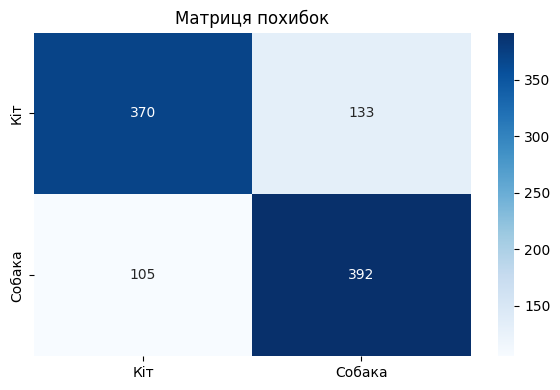

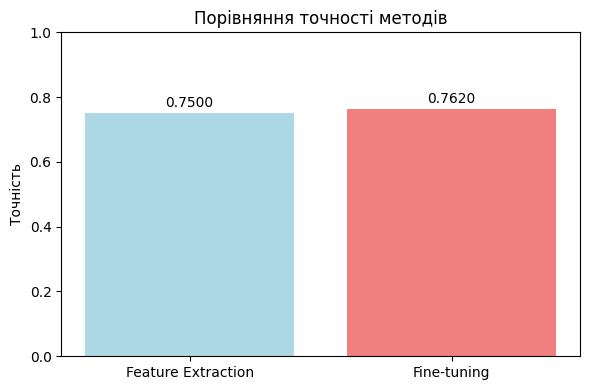

C:\Users\Admin\AppData\Local\Temp\ipykernel_29144\1418598058.py:168: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = int(y_true[idx])


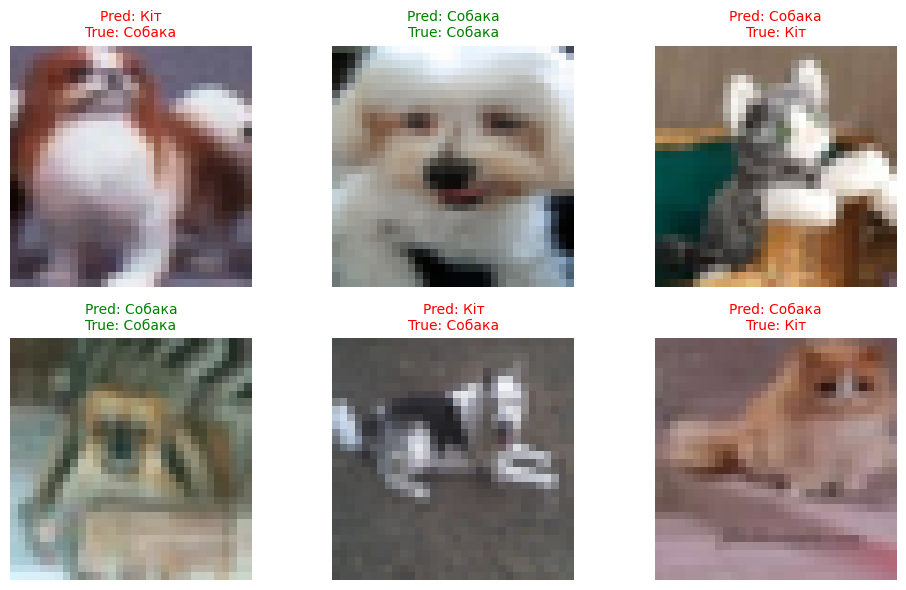


Результати:
Точність після Feature Extraction: 0.7500
Точність після Fine-tuning: 0.7620
Покращення: 0.0120
Fine-tuning покращив точність


In [3]:

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("Бібліотеки завантажено")
print("TensorFlow версія:", tf.__version__)


print("\nЗавантаження CIFAR-10 датасету")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

classes_to_use = [3, 5] 


def filter_classes_fast(x_data, y_data, classes):
    mask = (y_data == classes[0]) | (y_data == classes[1])
    mask = mask.flatten()
    x_filtered = x_data[mask]
    y_filtered = y_data[mask]
    y_filtered = np.where(y_filtered == classes[0], 0, 1)
    return x_filtered, y_filtered

x_train_filtered, y_train_filtered = filter_classes_fast(x_train, y_train, classes_to_use)
x_test_filtered, y_test_filtered = filter_classes_fast(x_test, y_test, classes_to_use)


SAMPLE_SIZE = 2000  
x_train_small = x_train_filtered[:SAMPLE_SIZE]
y_train_small = y_train_filtered[:SAMPLE_SIZE]
x_test_small = x_test_filtered[:1000]
y_test_small = y_test_filtered[:1000]

print(f"Тренувальні дані: {x_train_small.shape}")
print(f"Тестові дані: {x_test_small.shape}")


def preprocess_images_fast(images, target_size=(128, 128)):  
    images = tf.image.resize(images, target_size)
    images = tf.cast(images, tf.float32) / 255.0
    return images


batch_size = 32

train_dataset = tf.data.Dataset.from_tensor_slices((x_train_small, y_train_small))
train_dataset = train_dataset.map(lambda x, y: (preprocess_images_fast(x), y))
train_dataset = train_dataset.batch(batch_size).prefetch(2)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test_small, y_test_small))
test_dataset = test_dataset.map(lambda x, y: (preprocess_images_fast(x), y))
test_dataset = test_dataset.batch(batch_size).prefetch(2)


print("\nЗавантаження моделі")


base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3), 
    include_top=False,
    weights='imagenet',
    pooling='avg'  
)

base_model.trainable = False


model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()


print("Початок навчання:")
history_fe = model.fit(
    train_dataset,
    epochs=1,
    validation_data=test_dataset,
    verbose=1
)

print("\nОцінка після Feature Extraction:")
test_loss_fe, test_accuracy_fe = model.evaluate(test_dataset, verbose=0)
print(f"Точність на тестових даних: {test_accuracy_fe:.4f}")


print("\nFine-tuning:")
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model.fit(
    train_dataset,
    epochs=1,
    validation_data=test_dataset,
    verbose=1
)

print("\nОцінка після Fine-tuning:")
test_loss_ft, test_accuracy_ft = model.evaluate(test_dataset, verbose=0)
print(f"Точність на тестових даних: {test_accuracy_ft:.4f}")


print("\nВізуалізація результатів:")


y_pred_probs = model.predict(test_dataset, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_small

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Кіт', 'Собака'], 
            yticklabels=['Кіт', 'Собака'])
plt.title('Матриця похибок')
plt.tight_layout()
plt.show()


methods = ['Feature Extraction', 'Fine-tuning']
accuracies = [test_accuracy_fe, test_accuracy_ft]

plt.figure(figsize=(6, 4))
bars = plt.bar(methods, accuracies, color=['lightblue', 'lightcoral'])
plt.title('Порівняння точності методів')
plt.ylabel('Точність')
plt.ylim(0, 1)

for bar, accuracy in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{accuracy:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


class_names = ['Кіт', 'Собака']

def denormalize_image(image):
    return np.clip(image, 0, 1)

sample_indices = np.random.choice(len(x_test_small), 6, replace=False)

plt.figure(figsize=(10, 6))
for i, idx in enumerate(sample_indices):
    plt.subplot(2, 3, i + 1)
    
    test_image = x_test_small[idx]
    true_label = int(y_true[idx])
    predicted_label = int(y_pred[idx])
    
    display_image = test_image / 255.0
    plt.imshow(display_image)
    color = 'green' if predicted_label == true_label else 'red'
    plt.title(f'Pred: {class_names[predicted_label]}\nTrue: {class_names[true_label]}', 
              color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


print(f"\nРезультати:")
print(f"Точність після Feature Extraction: {test_accuracy_fe:.4f}")
print(f"Точність після Fine-tuning: {test_accuracy_ft:.4f}")
improvement = test_accuracy_ft - test_accuracy_fe
print(f"Покращення: {improvement:.4f}")

if improvement > 0:
    print("Fine-tuning покращив точність")
else:
    print("Fine-tuning не покращив точність (можливо, потрібно більше даних/епох)")
